In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [3]:
# Load city metadata
city_info = pd.read_csv('/home/lpsha/s154446/fractality/data/city_external/city_info.csv')

# Load degree sequences for t50_a10
data_path = '/home/lpsha/s154446/fractality/data/city_degrees/t50_a10/'
city_degrees = {}
for fname in os.listdir(data_path):
    city_name = fname.replace('.npz', '')
    d = np.load(os.path.join(data_path, fname))
    city_degrees[city_name] = d['degree']

# Match cities to metadata
city_info['degrees'] = city_info['city'].map(city_degrees)
city_info = city_info.dropna(subset=['degrees'])

# Create GDP bins
gdp_bins = [0, 5000, 15000, 30000, 50000, 200000]
gdp_labels = ['<5k', '5k-15k', '15k-30k', '30k-50k', '>50k']
city_info['gdp_group'] = pd.cut(city_info['country_gdp_per_capita_usd'], bins=gdp_bins, labels=gdp_labels)

city_info['N_nodes'] = city_info['degrees'].apply(len)
city_info = city_info[city_info['N_nodes'] > 500].copy()

def ratio(degrees):
    r = len(degrees[degrees <= 4]) / len(degrees)
    return r

city_info['degree_ratio'] = city_info['degrees'].apply(ratio)


city_info

,city,country,continent,latitude,longitude,population_city_proper,area_km2,population_density_per_km2,founding_era,street_pattern,country_gdp_per_capita_usd,climate_zone,elevation_m,coastal,degrees,gdp_group,N_nodes,degree_ratio
0,"Copenhagen, Denmark",Denmark,Europe,55.68,12.57,794128,88,9024,medieval,organic,67803,Cfb,14,yes,"[5, 27, 4, 3, 6, 7, 2, 26, 26, 37, 8, 2, 7, 4,...",>50k,160330,0.784052
2,"Perth, Australia",Australia,Oceania,-31.95,115.86,2085973,6418,325,colonial_19c,grid,51812,Csa,31,yes,"[12, 5, 32, 5, 6, 9, 4, 6, 3, 4, 3, 4, 11, 3, ...",>50k,1949,0.644433
3,"Santiago, Chile",Chile,South America,-33.45,-70.65,5614000,641,8758,colonial_16c,grid,16265,Csb,520,no,"[85, 100, 102, 11, 13, 3, 3, 5, 4, 4, 63, 5, 5...",15k-30k,3869,0.759886
4,Monaco,Monaco,Europe,43.74,7.42,39244,2,19622,medieval,organic,190512,Csa,62,yes,"[3, 15, 13, 3, 6, 16, 2, 10, 5, 7, 5, 9, 3, 6,...",>50k,2715,0.669245
5,"Puerto Vallarta, Mexico",Mexico,North America,20.65,-105.22,291839,121,2412,colonial_16c,organic,10045,Aw,2,yes,"[7, 11, 10, 9, 6, 11, 16, 5, 13, 6, 8, 4, 14, ...",5k-15k,7586,0.720011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,"Bratislava, Slovakia",Slovakia,Europe,48.15,17.11,475503,368,1292,medieval,organic,21088,Cfb,134,no,"[2, 15, 449, 1, 7, 237, 2, 4, 2, 4, 2, 7, 5, 2...",15k-30k,56532,0.733231
93,"Ljubljana, Slovenia",Slovenia,Europe,46.06,14.51,295504,164,1802,medieval,organic,28439,Cfb,295,no,"[22, 51, 38, 9, 5, 10, 3, 4, 4, 14, 11, 14, 12...",15k-30k,38056,0.777118
94,"Baku, Azerbaijan",Azerbaijan,Asia,40.41,49.87,2303000,2140,1076,ancient,organic,7723,BSk,-28,yes,"[4, 3, 34, 4, 3, 4, 4, 3, 3, 3, 3, 4, 3, 1, 1,...",5k-15k,85100,0.821504
95,"Minsk, Belarus",Belarus,Europe,53.90,27.57,2009786,349,5759,medieval,radial,7302,Dfb,220,no,"[36, 8, 3, 15, 4, 6, 9, 6, 5, 4, 2, 4, 2, 4, 4...",5k-15k,126129,0.693124


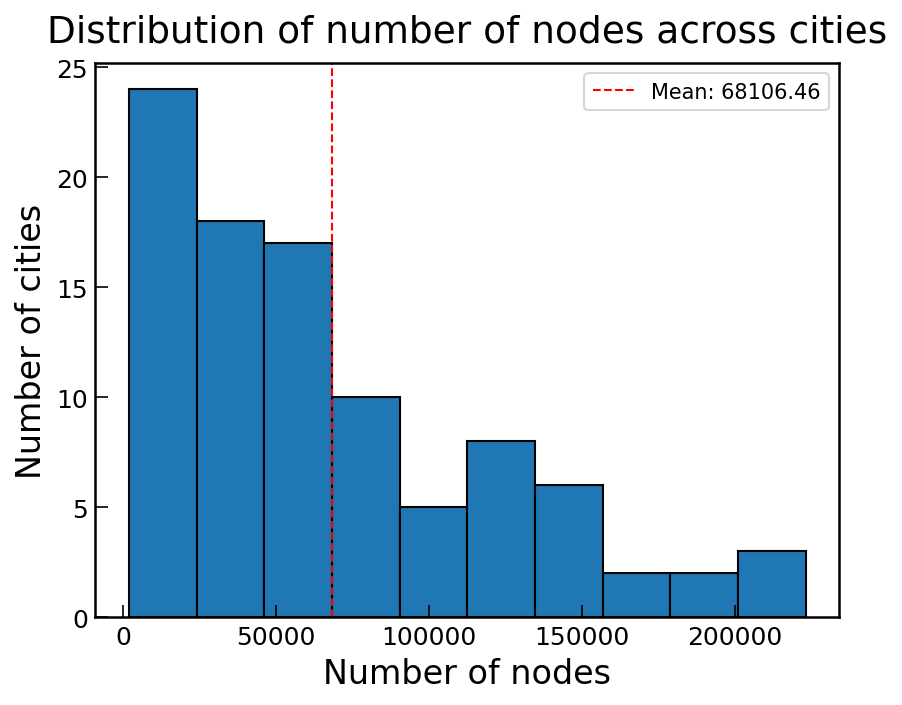

In [4]:
plt.hist(city_info['N_nodes'],bins=10, edgecolor='black')
plt.xlabel('Number of nodes')
m = city_info['N_nodes'].mean()
plt.axvline(m, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {m:.2f}')
plt.legend()
plt.ylabel('Number of cities')
plt.title('Distribution of number of nodes across cities')
plt.show()

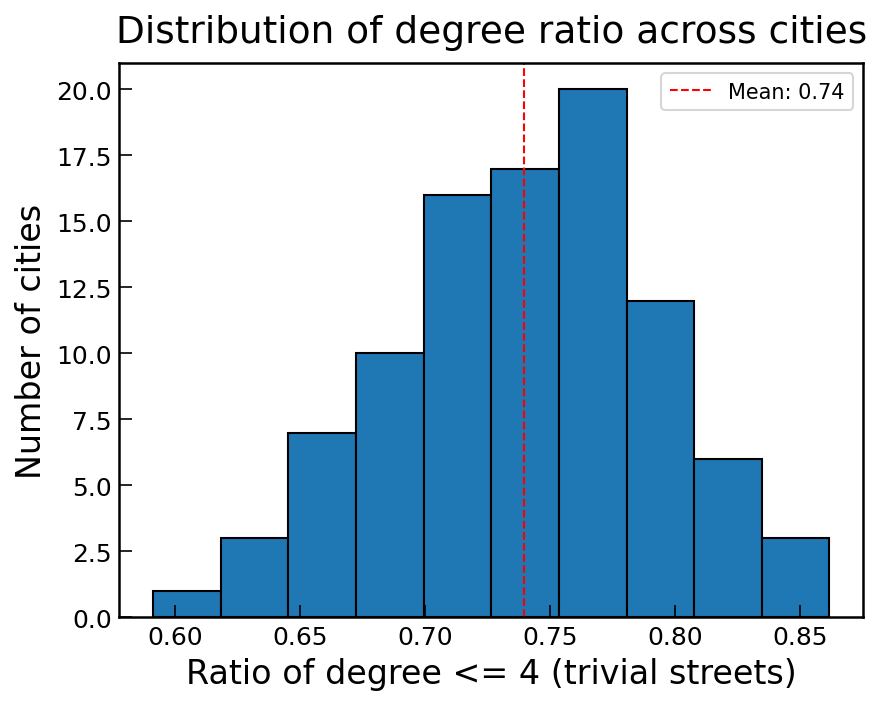

In [5]:
plt.hist(city_info['degree_ratio'],bins=10, edgecolor='black')
plt.xlabel('Ratio of degree <= 4 (trivial streets)')
m = city_info['degree_ratio'].mean()
plt.axvline(m, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {m:.2f}')
plt.legend()
plt.ylabel('Number of cities')
plt.title('Distribution of degree ratio across cities')
plt.show()

Slope: -5.2356, Intercept: 8.1670, R-squared: 0.2829, p-value: 2.9123e-08


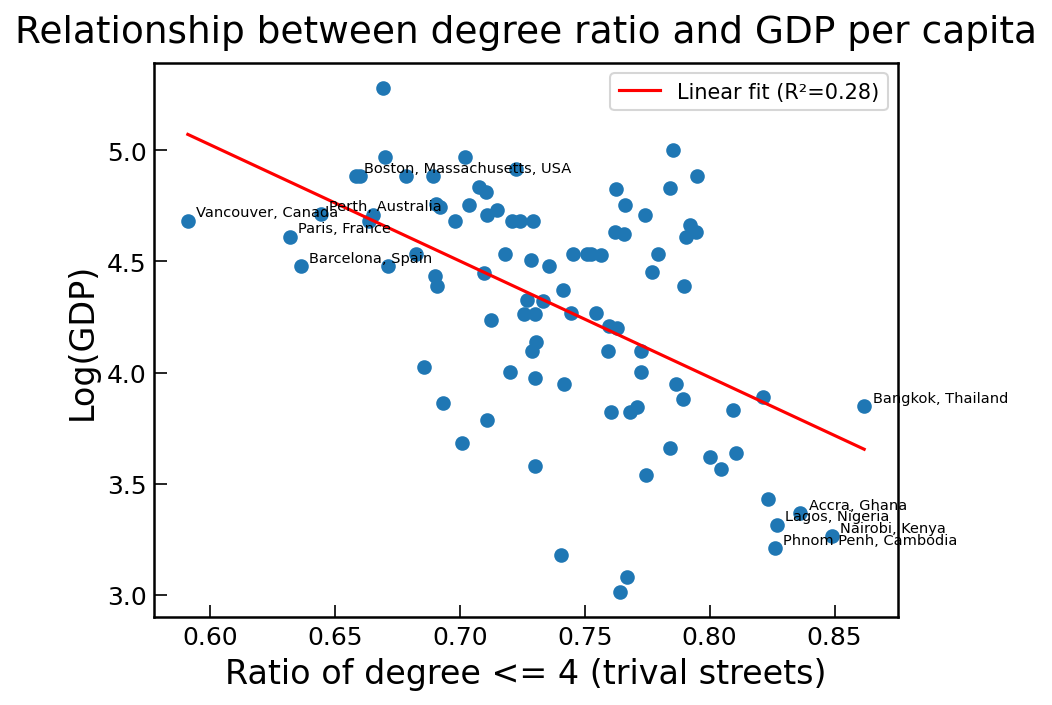

In [6]:
x=city_info['degree_ratio']
y=city_info['country_gdp_per_capita_usd'].apply(lambda gdp: np.log10(gdp) if gdp > 0 else 0)

# linreg
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R-squared: {r_value**2:.4f}, p-value: {p_value:.4e}")

# plot
xs = np.linspace(x.min(), x.max(), 100)
ys = intercept + slope * xs
plt.plot(xs, ys, color='red', label=f'Linear fit (R²={r_value**2:.2f})')

plt.legend()
plt.xlabel('Ratio of degree <= 4 (trival streets)')
plt.ylabel('Log(GDP)')
plt.title('Relationship between degree ratio and GDP per capita')


for i in range(1, 6):
    row = city_info.loc[city_info['degree_ratio'].nsmallest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], 
                               np.log10(row["country_gdp_per_capita_usd"]) if row["country_gdp_per_capita_usd"] > 0 else 0), 
                               fontsize=7,
                               xytext=(4, 2), textcoords="offset points")

for i in range(1, 6):
    row=city_info.loc[city_info['degree_ratio'].nlargest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], 
                            np.log10(row["country_gdp_per_capita_usd"]) if row["country_gdp_per_capita_usd"] > 0 else 0), 
                            fontsize=7,
                            xytext=(4, 2), textcoords="offset points")

plt.scatter(x, y)
plt.show()

Slope: 25425997.2408, Intercept: -15861967.6676, R-squared: 0.1143, p-value: 8.0438e-04


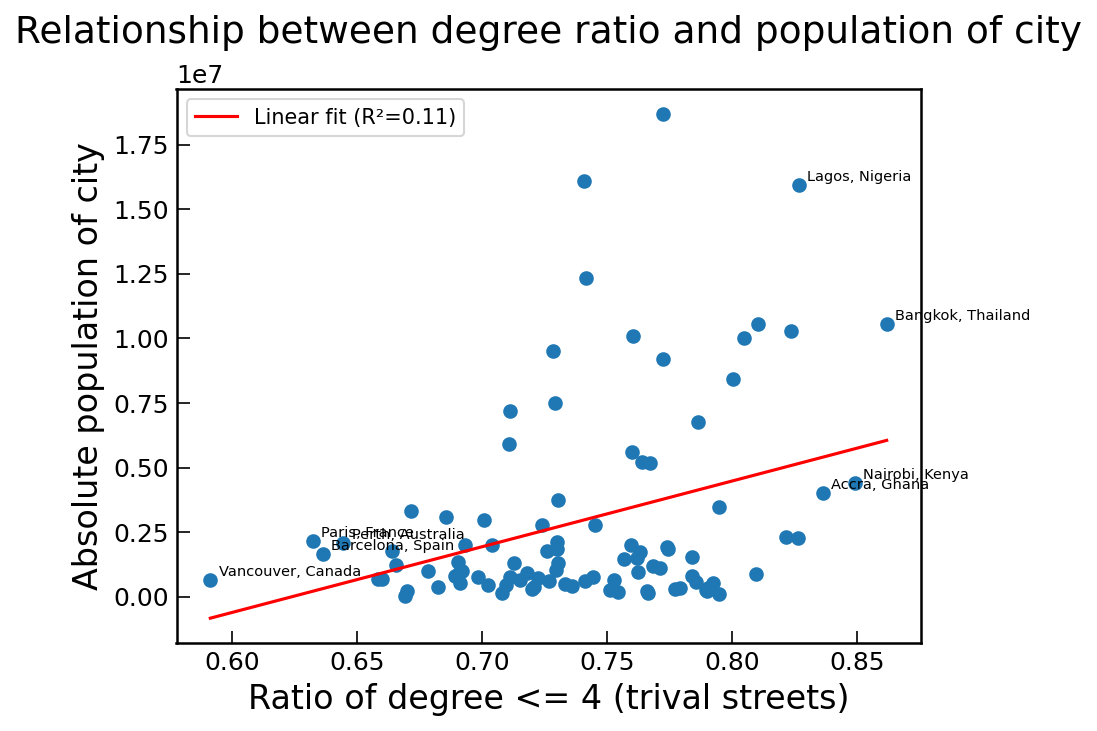

In [7]:
x=city_info['degree_ratio']
y=city_info['population_city_proper']

# linreg
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R-squared: {r_value**2:.4f}, p-value: {p_value:.4e}")

# plot
xs = np.linspace(x.min(), x.max(), 100)
ys = intercept + slope * xs
plt.plot(xs, ys, color='red', label=f'Linear fit (R²={r_value**2:.2f})')

plt.legend()
plt.xlabel('Ratio of degree <= 4 (trival streets)')
plt.ylabel('Absolute population of city')
plt.title('Relationship between degree ratio and population of city')


for i in range(1, 5):
    row = city_info.loc[city_info['degree_ratio'].nsmallest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], row["population_city_proper"]), fontsize=7,
                               xytext=(4, 2), textcoords="offset points")

for i in range(1, 5):
    row=city_info.loc[city_info['degree_ratio'].nlargest(i).index[-1]]
    plt.annotate(row["city"], (row["degree_ratio"], row["population_city_proper"]), fontsize=7,
                            xytext=(4, 2), textcoords="offset points")

plt.scatter(x, y)
plt.show()

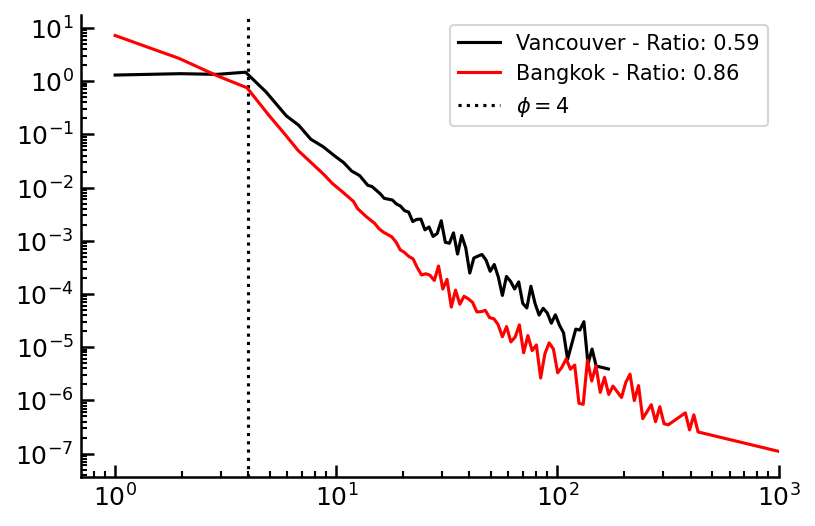

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

van=city_info[city_info.city == 'Vancouver, Canada']
d=np.array(van.degrees)[0]
y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k',label='Vancouver - Ratio: '+str(np.round(van.degree_ratio.values[0],2)))

ban=city_info[city_info.city == 'Bangkok, Thailand']
d=np.array(ban.degrees)[0]
y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='r',label='Bangkok - Ratio: '+str(np.round(ban.degree_ratio.values[0],2)))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)
plt.xscale('log')
plt.yscale('log')
ax.set_xlim(right=1000)


ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4),zorder=-1)
plt.legend()
plt.show()

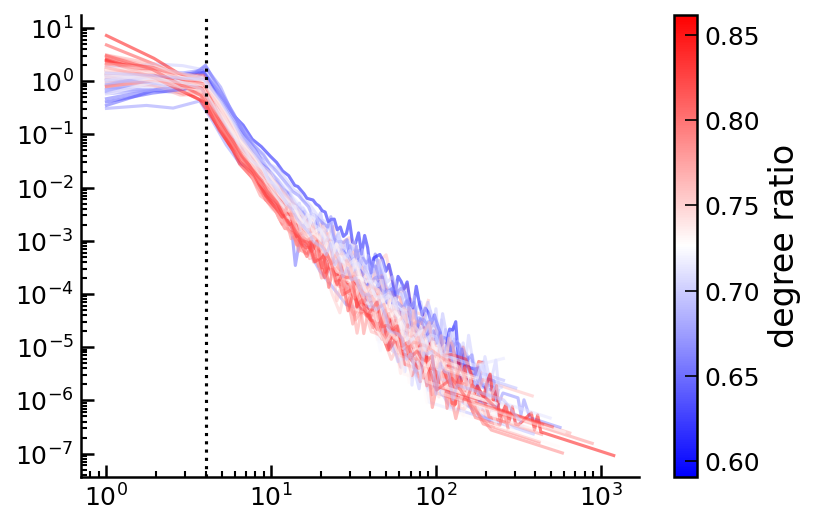

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(6, 4))

# Set up colormap based on degree_ratio range
norm = Normalize(vmin=city_info['degree_ratio'].min(),
                 vmax=city_info['degree_ratio'].max())
cmap = plt.cm.bwr  # pick any: viridis, plasma, coolwarm, etc.

for row, city in city_info.iterrows():
    ratio = city.degree_ratio
    dd = city.degrees
    d = np.array(dd)
    y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.5, zorder=2, color=cmap(norm(ratio)))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)
plt.xscale('log')
plt.yscale('log')
# ax.set_xlim(right=1000)

ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4), zorder=10)

# Add colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('degree ratio')

plt.show()

In [10]:
print('Trivial edges (d <= 4):', len(d[d <= 4]))
print('Non-trivial edges (d > 4):', len(d[d > 4]))

Trivial edges (d <= 4): 11211
Non-trivial edges (d > 4): 4521


# Orientation Entropy

In [11]:
DATA_DIR = os.path.join('..', 'data', 'city_orientations')
BIN_EDGES = np.arange(-5.0, 356.0, 10.0)
assert len(BIN_EDGES) == 37  # 36 bins

In [12]:
def orientation_entropy(bearings, weights=None):
    """Shannon entropy (nats) of a bearing distribution on 36 bins shifted by -5°."""
    b = np.asarray(bearings, dtype=float)
    b = b[np.isfinite(b)]
    # wrap [355, 360) into the first bin [-5, 5)
    b = np.where(b >= 355.0, b - 360.0, b)
    w = None if weights is None else np.asarray(weights, dtype=float)[np.isfinite(b)]
    counts, _ = np.histogram(b, bins=BIN_EDGES, weights=w)
    total = counts.sum()
    if total <= 0:
        return np.nan
    p = counts / total
    nz = p > 0
    return float(-(p[nz] * np.log(p[nz])).sum())

rows = []
for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith('.npz'):
        continue
    city = os.path.splitext(fname)[0]
    d = np.load(os.path.join(DATA_DIR, fname))
    H_o = orientation_entropy(d['method1_bearings'])
    rows.append({'city': city, 'n_edges': len(d['method1_bearings']) // 2, 'H_o': H_o})

df = pd.DataFrame(rows).sort_values('H_o').reset_index(drop=True)

rows = []
for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith('.npz'):
        continue
    city = os.path.splitext(fname)[0]
    d = np.load(os.path.join(DATA_DIR, fname))
    H_o = orientation_entropy(d['method1_bearings'])
    H_w = orientation_entropy(d['method2_bearings'], d['method2_weights'])
    rows.append({'city': city, 'H_o': H_o, 'H_w': H_w})

df = pd.DataFrame(rows).sort_values('H_w').reset_index(drop=True)

H_MAX = np.log(36)  # ≈ 3.584
H_G   = np.log(4)   # ≈ 1.386

def phi(H):
    return 1.0 - ((H - H_G) / (H_MAX - H_G)) ** 2

df['phi_o'] = phi(df['H_o'])
df['phi_w'] = phi(df['H_w'])
df.sort_values('phi_w', ascending=False).reset_index(drop=True)

,city,H_o,H_w,phi_o,phi_w
0,"Vancouver,_Canada",2.607569,2.500012,0.691058,0.743078
1,"Luxembourg_City,_Luxembourg",2.967800,2.586814,0.481925,0.701469
2,"Santiago,_Chile",3.049709,2.856813,0.426871,0.552089
3,"Toronto,_Canada",3.020325,2.921610,0.446941,0.511745
4,"Perth,_Australia",3.024063,2.939097,0.444408,0.500560
...,...,...,...,...,...
92,"Palma_de_Mallorca,_Spain",3.573205,3.577298,0.009366,0.005655
93,"Hanoi,_Vietnam",3.577444,3.577599,0.005522,0.005381
94,"Hong_Kong,_China",3.576067,3.577998,0.006771,0.005019
95,"Rome,_Italy",3.578591,3.579277,0.004480,0.003857


In [13]:
df['city'] = df['city'].str.replace('_', ' ')

In [14]:
df

,city,H_o,H_w,phi_o,phi_w
0,"Vancouver, Canada",2.607569,2.500012,0.691058,0.743078
1,"Luxembourg City, Luxembourg",2.967800,2.586814,0.481925,0.701469
2,"Santiago, Chile",3.049709,2.856813,0.426871,0.552089
3,"Toronto, Canada",3.020325,2.921610,0.446941,0.511745
4,"Perth, Australia",3.024063,2.939097,0.444408,0.500560
...,...,...,...,...,...
92,"Palma de Mallorca, Spain",3.573205,3.577298,0.009366,0.005655
93,"Hanoi, Vietnam",3.577444,3.577599,0.005522,0.005381
94,"Hong Kong, China",3.576067,3.577998,0.006771,0.005019
95,"Rome, Italy",3.578591,3.579277,0.004480,0.003857


In [15]:
city_info['phi_w'] = city_info['city'].map(df.set_index('city')['phi_w'])
city_info['H_w'] = city_info['city'].map(df.set_index('city')['H_w'])
city_info['phi_o'] = city_info['city'].map(df.set_index('city')['phi_o'])
city_info['H_o'] = city_info['city'].map(df.set_index('city')['H_o'])

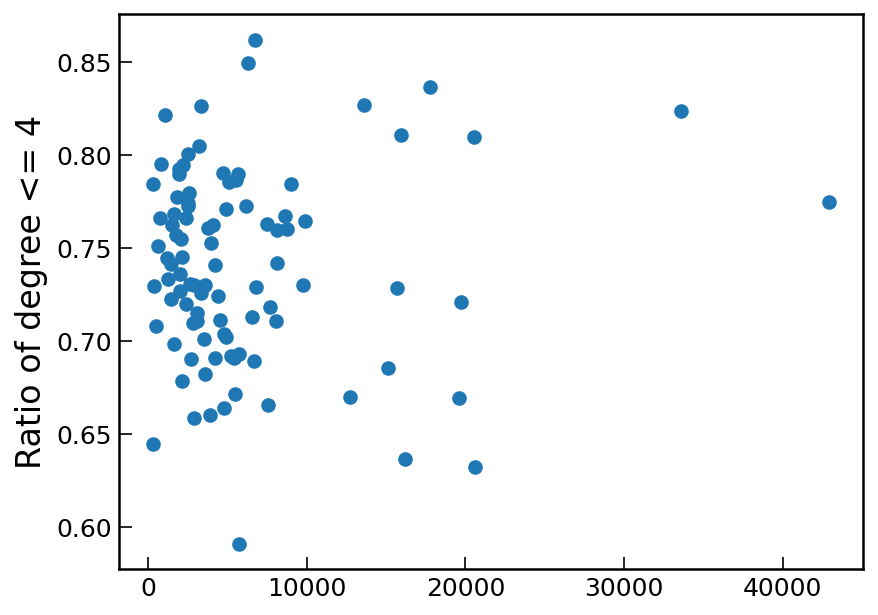

In [16]:
x=city_info['population_density_per_km2']
y=city_info['degree_ratio']

plt.scatter(x, y)
# plt.xlabel('Phi (orientation order)')
plt.ylabel('Ratio of degree <= 4') # (trivial streets)
# plt.title('Relationship between orientation order and degree ratio')
plt.show()

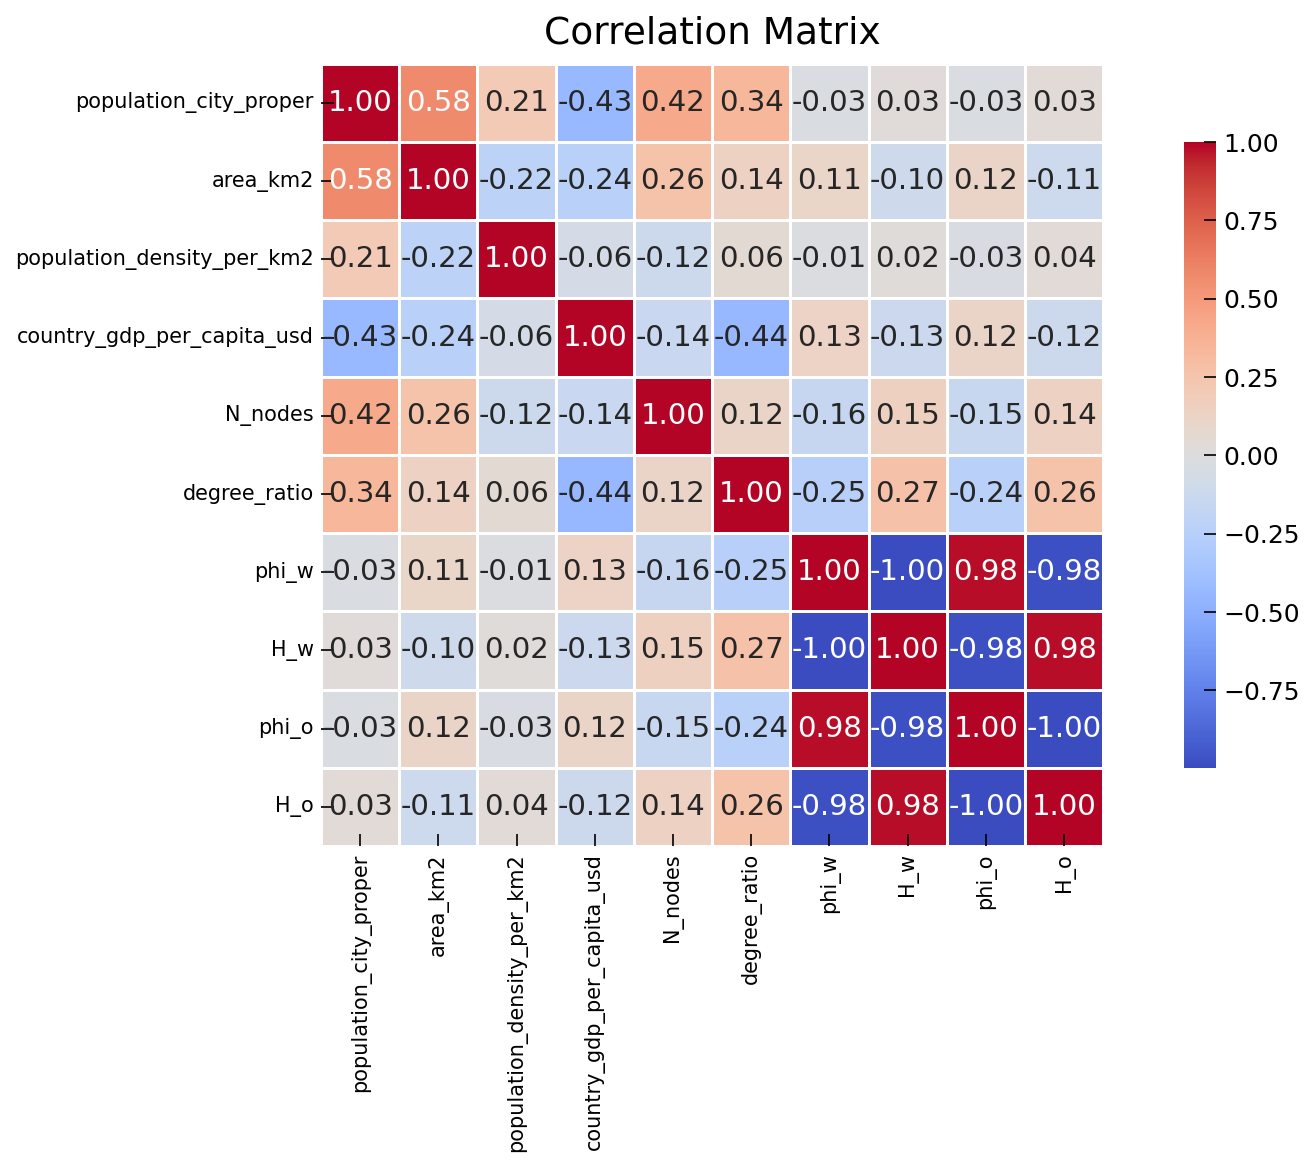

In [17]:
num_cols=['population_city_proper','area_km2','population_density_per_km2','country_gdp_per_capita_usd','N_nodes','degree_ratio','phi_w','H_w','phi_o','H_o']

corr = city_info[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix")

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
import umap

In [19]:
num_cols=['population_city_proper','area_km2','population_density_per_km2','country_gdp_per_capita_usd','N_nodes','phi_w','H_w','phi_o','H_o']
X = city_info[num_cols]
y = city_info['degree_ratio']

In [20]:
X

,population_city_proper,area_km2,population_density_per_km2,country_gdp_per_capita_usd,N_nodes,phi_w,H_w,phi_o,H_o
0,794128,88,9024,67803,160330,0.050594,3.527214,0.053346,3.524110
2,2085973,6418,325,51812,1949,0.500560,2.939097,0.444408,3.024063
3,5614000,641,8758,16265,3869,0.552089,2.856813,0.426871,3.049709
4,39244,2,19622,190512,2715,0.064275,3.511733,0.030681,3.549550
5,291839,121,2412,10045,7586,0.044521,3.534050,0.049608,3.528326
...,...,...,...,...,...,...,...,...,...
92,475503,368,1292,21088,56532,0.037039,3.542444,0.038402,3.540916
93,295504,164,1802,28439,38056,0.015075,3.566895,0.025170,3.555691
94,2303000,2140,1076,7723,85100,0.049222,3.528761,0.045344,3.533125
95,2009786,349,5759,7302,126129,0.021243,3.560056,0.016512,3.565303


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


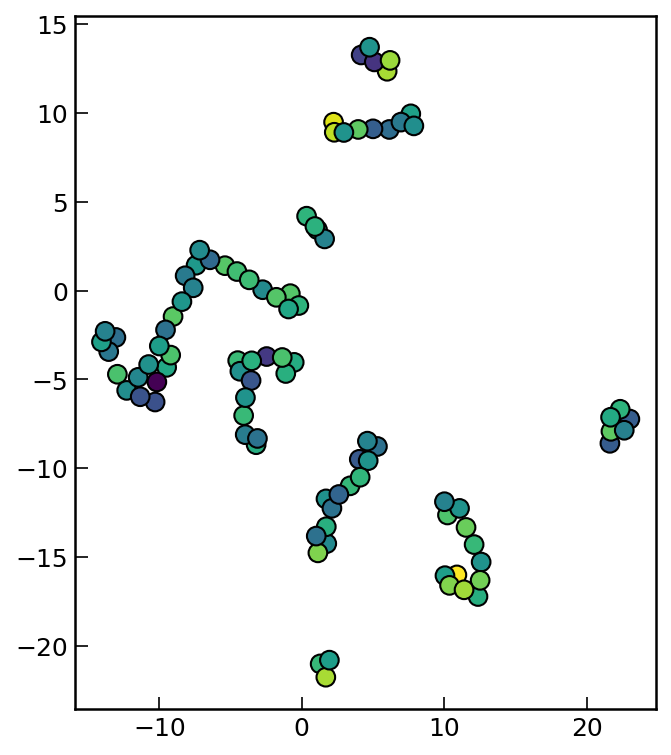

In [21]:
umap_model = umap.UMAP(n_components=2,min_dist=1,n_neighbors=3)
X_embedded = umap_model.fit_transform(X,y=y)

fig, ax = plt.subplots(figsize=(5, 6))
ax.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap='viridis', edgecolor='k', s=80)

plt.show()

Using 95 rows
[0.06135055 0.29083955]
CV R²: 0.176 ± 0.115


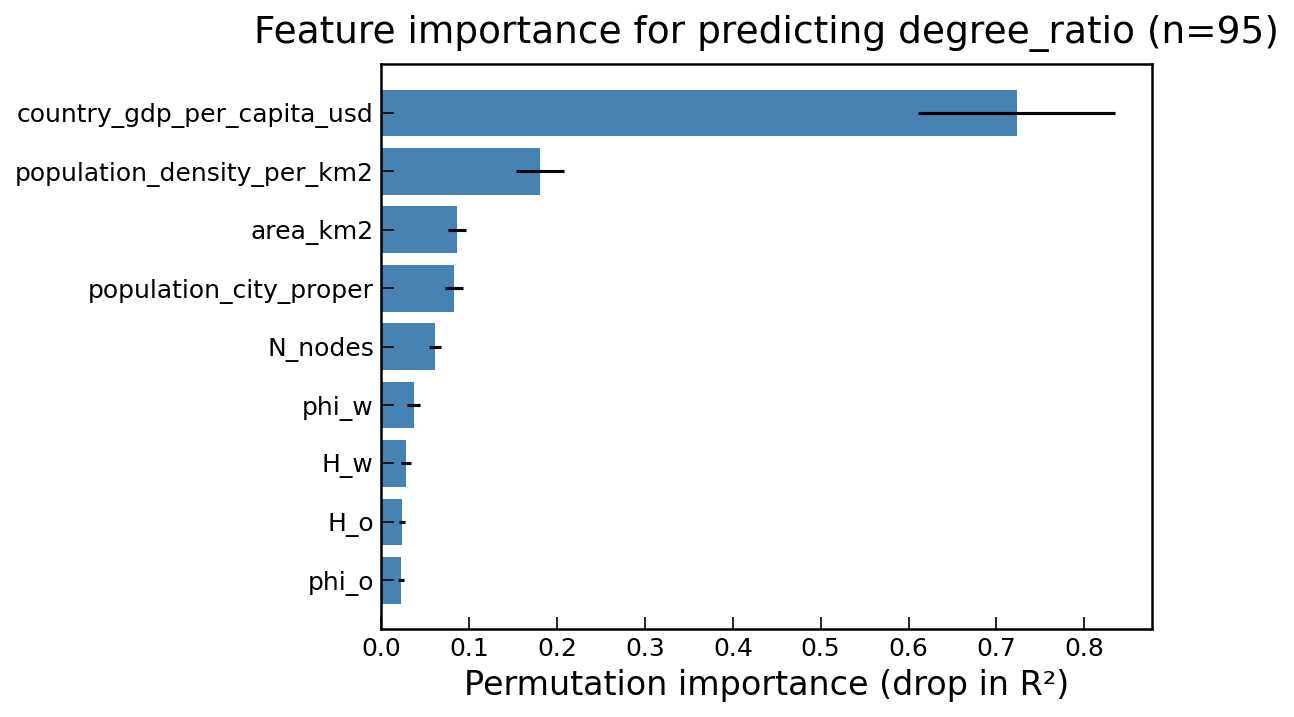

                   feature  importance_mean  importance_std
country_gdp_per_capita_usd         0.723067        0.112096
population_density_per_km2         0.180823        0.027587
                  area_km2         0.085804        0.010248
    population_city_proper         0.082921        0.010149
                   N_nodes         0.061018        0.006920
                     phi_w         0.037096        0.007239
                       H_w         0.028254        0.005580
                       H_o         0.023478        0.003609
                     phi_o         0.022327        0.003324


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_cols = ['population_city_proper', 'area_km2', 'population_density_per_km2',
            'country_gdp_per_capita_usd', 'N_nodes', 'phi_w', 'H_w', 'phi_o', 'H_o']
X = city_info[num_cols]
y = city_info['degree_ratio']

# drop rows with NaNs in features or target
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]
print(f"Using {len(X)} rows")

# small dataset → shallow trees, modest forest
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

# sanity-check generalization first
cv = KFold(n_splits=2, shuffle=True)
r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
print(r2_scores)
print(f"CV R²: {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")

# fit on full data, then permutation importance with repeats for stability
model.fit(X, y)
result = permutation_importance(
    model, X, y,
    n_repeats=30,
    random_state=42,
    scoring='r2',
    n_jobs=-1,
)

imp_df = pd.DataFrame({
    'feature': num_cols,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std,
}).sort_values('importance_mean', ascending=True)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance_mean'],
        xerr=imp_df['importance_std'], color='steelblue')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Permutation importance (drop in R²)')
ax.set_title(f'Feature importance for predicting degree_ratio (n={len(X)})')
fig.tight_layout()
plt.show()

print(imp_df.iloc[::-1].to_string(index=False))